In [ ]:
# =========================================================
# Install Library
# =========================================================

# !pip install pandas_ta xgboost scikit-learn requests ta

In [ ]:
# =========================================================
# Import Library
# =========================================================

import requests
import pandas as pd
import numpy as np
import datetime
import time
import warnings
import pickle

# Technical Analysis
import pandas_ta as ta

# Machine Learning
import xgboost as xgb

# Validation
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import randint, uniform

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, precision_recall_curve
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# =========================================================
# Fetch Historical Bitcoin Data from Coinbase Exchange API
# =========================================================

def fetch_coinbase_data(product_id="BTC-USD", granularity=3600, total_candles=25000):
    url = f"https://api.exchange.coinbase.com/products/{product_id}/candles"
    all_data = []
    limit = 300
    end_time = datetime.datetime.now(datetime.timezone.utc)

    while len(all_data) < total_candles:
        start_time = end_time - datetime.timedelta(seconds=granularity * limit)
        params = {"start": start_time.isoformat(), "end": end_time.isoformat(), "granularity": granularity}
        try:
            response = requests.get(url, params=params, timeout=15)
            if response.status_code != 200: break
            data = response.json()
            if not data: break
            all_data.extend(data)
            end_time = start_time
            time.sleep(0.3)
        except Exception:
            break

    # Coinbase Format: [time, low, high, open, close, volume]
    df = pd.DataFrame(all_data, columns=["time", "low", "high", "open", "close", "volume"])

    # Convert Timestamp
    df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)

    # Sort Chronologically
    df = df.sort_values("time").drop_duplicates(subset=["time"]).tail(total_candles).reset_index(drop=True)

    return df

# Download Dataset
df = fetch_coinbase_data(product_id="BTC-USD", granularity=3600, total_candles=25000)
df.head()

,time,low,high,open,close,volume
0,2023-08-19 13:00:00+00:00,25900.00,25973.55,25905.47,25918.08,182.758399
1,2023-08-19 14:00:00+00:00,25913.07,26041.09,25918.08,25975.18,375.140723
2,2023-08-19 15:00:00+00:00,25951.36,26221.65,25975.17,26209.49,635.157804
3,2023-08-19 16:00:00+00:00,26109.04,26269.11,26209.48,26243.96,602.860086
4,2023-08-19 17:00:00+00:00,26065.54,26246.36,26244.79,26086.83,349.133602


In [ ]:
# =========================================================
# Fetch Historical Bitcoin Data 4H (Multi-Timeframe)
# =========================================================

df_4h = (
    df
    .set_index("time")
    .resample("4h")
    .agg({
        "open":"first",
        "high":"max",
        "low":"min",
        "close":"last",
        "volume":"sum"
    })
    .dropna()
    .reset_index()
)

df_4h.head()

,time,open,high,low,close,volume
0,2023-08-19 12:00:00+00:00,25905.47,26221.65,25900.00,26209.49,1193.056926
1,2023-08-19 16:00:00+00:00,26209.48,26269.11,26024.43,26125.01,1410.991811
2,2023-08-19 20:00:00+00:00,26125.00,26155.98,26029.78,26096.42,772.050291
3,2023-08-20 00:00:00+00:00,26096.40,26203.79,26041.25,26101.74,647.987813
4,2023-08-20 04:00:00+00:00,26101.73,26160.22,26043.01,26089.14,443.581394


In [ ]:
# =========================================================
# Target Label Construction
# =========================================================

THRESHOLD_PERCENT = 0.10

# Future Close Price
df["next_close"] = df["close"].shift(-1)

# Future Percentage Return
df["future_return"] = ((df["next_close"] - df["close"]) / df["close"]) * 100

# Binary Classification Target
# 1 = Significant Uptrend
# 0 = Sideways / Downtrend

df["target"] = (df["future_return"] > THRESHOLD_PERCENT).astype(int)

# Remove Last Observation Without Future Price
df = df.dropna().reset_index(drop=True)
df.head()

,time,low,high,open,close,volume,next_close,future_return,target
0,2023-08-19 13:00:00+00:00,25900.00,25973.55,25905.47,25918.08,182.758399,25975.18,0.220310,1
1,2023-08-19 14:00:00+00:00,25913.07,26041.09,25918.08,25975.18,375.140723,26209.49,0.902053,1
2,2023-08-19 15:00:00+00:00,25951.36,26221.65,25975.17,26209.49,635.157804,26243.96,0.131517,1
3,2023-08-19 16:00:00+00:00,26109.04,26269.11,26209.48,26243.96,602.860086,26086.83,-0.598728,0
4,2023-08-19 17:00:00+00:00,26065.54,26246.36,26244.79,26086.83,349.133602,26121.49,0.132864,1


In [ ]:
# =========================================================
# Target Distribution Analysis
# =========================================================

target_distribution = (
    df["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_distribution

target
0    62.54
1    37.46
Name: proportion, dtype: float64

In [ ]:
# =========================================================
# Feature Engineering (1H)
# =========================================================

def add_technical_indicators(data):
    df_ta = data.copy()

    # -----------------------------------------------------
    # A. Trend Indicators
    # -----------------------------------------------------
    sma_10 = ta.sma(df_ta['close'], length=10)
    sma_50 = ta.sma(df_ta['close'], length=50)
    ema_10 = ta.ema(df_ta['close'], length=10)
    ema_50 = ta.ema(df_ta['close'], length=50)

    df_ta['dist_sma_10'] = (df_ta['close'] - sma_10) / sma_10
    df_ta['dist_sma_50'] = (df_ta['close'] - sma_50) / sma_50
    df_ta['dist_ema_10'] = (df_ta['close'] - ema_10) / ema_10
    df_ta['dist_ema_50'] = (df_ta['close'] - ema_50) / ema_50

    df_ta['sma_10_50_ratio'] = sma_10 / sma_50

    df_ta['ADX_14'] = ta.adx(df_ta['high'], df_ta['low'], df_ta['close'])['ADX_14']

    # -----------------------------------------------------
    # B. Momentum & Oscillators
    # -----------------------------------------------------
    df_ta['RSI_14'] = ta.rsi(df_ta['close'], length=14)
    stoch = ta.stoch(df_ta['high'], df_ta['low'], df_ta['close'])
    df_ta['Stoch_K'] = stoch['STOCHk_14_3_3']
    df_ta['Stoch_D'] = stoch['STOCHd_14_3_3']
    df_ta['CCI_14'] = ta.cci(df_ta['high'], df_ta['low'], df_ta['close'], length=14)
    df_ta['ROC_10'] = ta.roc(df_ta['close'], length=10)
    df_ta['WILLR_14'] = ta.willr(df_ta['high'], df_ta['low'], df_ta['close'], length=14)

    macd = ta.macd(df_ta['close'])
    df_ta['MACD_HIST'] = macd['MACDh_12_26_9']

    # -----------------------------------------------------
    # C. Volatility & Bands
    # -----------------------------------------------------
    bb = ta.bbands(df_ta['close'], length=20, std=2)
    df_ta['BB_PCT_B'] = bb.iloc[:, 4]
    df_ta['BB_WIDTH'] = bb.iloc[:, 3]

    df_ta['ATR_14'] = ta.atr(df_ta['high'], df_ta['low'], df_ta['close'], length=14)
    df_ta['atr_ratio'] = df_ta['ATR_14'] / df_ta['close']

    # -----------------------------------------------------
    # D. Historical Returns
    # -----------------------------------------------------
    df_ta['return_1h'] = df_ta['close'].pct_change(1)
    df_ta['return_3h'] = df_ta['close'].pct_change(3)
    df_ta['return_6h'] = df_ta['close'].pct_change(6)
    df_ta['return_24h'] = df_ta['close'].pct_change(24)

    df_ta['volatility_6h'] = df_ta['return_1h'].rolling(6).std()
    df_ta['volatility_24h'] = df_ta['return_1h'].rolling(24).std()

    df_ta['volatility_ratio'] = (df_ta['volatility_6h'] /(df_ta['volatility_24h'] + 1e-8))

    # -----------------------------------------------------
    # E. Volume
    # -----------------------------------------------------
    df_ta['volume_ratio_24h'] = df_ta['volume'] / df_ta['volume'].rolling(24).mean()
    df_ta['CMF_20'] = ta.cmf(df_ta['high'], df_ta['low'], df_ta['close'], df_ta['volume'], length=20)

    # -----------------------------------------------------
    # F. Candlestick
    # -----------------------------------------------------
    body = abs(df_ta['close'] - df_ta['open'])
    lower_shadow = (df_ta[['open', 'close']].min(axis=1) - df_ta['low'])
    upper_shadow = (df_ta['high'] - df_ta[['open', 'close']].max(axis=1))

    df_ta['body_ratio'] = body / df_ta['close']
    df_ta['upper_shadow_ratio'] = upper_shadow / df_ta['close']
    df_ta['lower_shadow_ratio'] = lower_shadow / df_ta['close']

    cols_to_drop = ['open', 'high', 'low', 'close', 'volume', 'ATR_14']
    df_ta = df_ta.drop(columns=cols_to_drop)

    # -----------------------------------------------------
    # G. Temporal Features
    # -----------------------------------------------------
    df_ta['hour'] = df_ta['time'].dt.hour
    df_ta['day_of_week'] = df_ta['time'].dt.dayofweek
    df_ta['is_weekend'] = np.where(df_ta['day_of_week'] > 4, 1, 0)

    df_ta['hour_sin'] = np.sin(2 * np.pi * df_ta['hour']/24.0)
    df_ta['hour_cos'] = np.cos(2 * np.pi * df_ta['hour']/24.0)

    df_ta = df_ta.drop(columns=['hour'])

    # -----------------------------------------------------
    # H. Lag Features
    # -----------------------------------------------------
    df_ta['return_1h_lag1'] = df_ta['return_1h'].shift(1)
    df_ta['return_1h_lag2'] = df_ta['return_1h'].shift(2)
    df_ta['return_1h_lag3'] = df_ta['return_1h'].shift(3)

    df_ta['return_3h_lag1'] = df_ta['return_3h'].shift(1)
    df_ta['return_3h_lag2'] = df_ta['return_3h'].shift(2)

    return df_ta

In [ ]:
# =========================================================
# Apply Feature Engineering
# =========================================================

df = add_technical_indicators(df)
df = df.dropna().reset_index(drop=True)
print(f"Data Size After Feature Engineering: {df.shape}")

Data Size After Feature Engineering: (24950, 41)


In [ ]:
# =========================================================
# Multi-Timeframe Feature Engineering (4H)
# =========================================================

def add_technical_indicators_4h(data):
    df_ta = data.copy()

    # -----------------------------------------------------
    # A. Trend Indicators
    # -----------------------------------------------------
    sma_20 = ta.sma(df_ta['close'], length=20)
    sma_50 = ta.sma(df_ta['close'], length=50)

    ema_20 = ta.ema(df_ta['close'], length=20)
    ema_50 = ta.ema(df_ta['close'], length=50)

    df_ta['dist_sma20_4H'] = ((df_ta['close'] - sma_20) / sma_20)
    df_ta['dist_sma50_4H'] = ((df_ta['close'] - sma_50) / sma_50)

    df_ta['dist_ema20_4H'] = ((df_ta['close'] - ema_20) / ema_20)
    df_ta['dist_ema50_4H'] = ((df_ta['close'] - ema_50) / ema_50)

    df_ta['sma20_50_ratio_4H'] = (sma_20 / sma_50)

    # -----------------------------------------------------
    # B. Momentum Indicators
    # -----------------------------------------------------
    df_ta['RSI_14_4H'] = ta.rsi(df_ta['close'], length=14)

    stoch = ta.stoch(df_ta['high'], df_ta['low'], df_ta['close'])

    df_ta['Stoch_K_4H'] = stoch.iloc[:, 0]
    df_ta['Stoch_D_4H'] = stoch.iloc[:, 1]

    macd = ta.macd(df_ta['close'])

    if macd is not None:
        df_ta['MACD_HIST_4H'] = macd.iloc[:, 2]
    else:
        df_ta['MACD_HIST_4H'] = np.nan

    # -----------------------------------------------------
    # C. Volatility Indicators
    # -----------------------------------------------------
    atr = ta.atr(df_ta['high'], df_ta['low'], df_ta['close'], length=14)

    df_ta['ATR_RATIO_4H'] = (atr / df_ta['close'])

    bb = ta.bbands(df_ta['close'], length=20, std=2)

    if bb is not None:
        df_ta['BB_WIDTH_4H'] = bb.iloc[:, 3]
    else:
        df_ta['BB_WIDTH_4H'] = np.nan

    # -----------------------------------------------------
    # D. Historical Return
    # -----------------------------------------------------
    df_ta['return_4H'] = (df_ta['close'].pct_change(1))
    df_ta['return_12H'] = (df_ta['close'].pct_change(3))
    df_ta['return_24H_4H'] = (df_ta['close'].pct_change(6))

    # -----------------------------------------------------
    # E. Volatility Features
    # -----------------------------------------------------
    df_ta['volatility_4H'] = (df_ta['return_4H'].rolling(6).std())
    df_ta['volatility_24H_4H'] = (df_ta['return_4H'].rolling(24).std())

    # -----------------------------------------------------
    # F. Volume Features
    # -----------------------------------------------------
    df_ta['volume_ratio_4H'] = (df_ta['volume'] / df_ta['volume'].rolling(20).mean())

    df_ta['CMF_20_4H'] = ta.cmf(df_ta['high'], df_ta['low'], df_ta['close'], df_ta['volume'], length=20)

    # -----------------------------------------------------
    # G. Output Features
    # -----------------------------------------------------
    return df_ta[
        [
            'time',

            'dist_sma20_4H',
            'dist_sma50_4H',
            'dist_ema20_4H',
            'dist_ema50_4H',
            'sma20_50_ratio_4H',

            'RSI_14_4H',
            'Stoch_K_4H',
            'Stoch_D_4H',
            'MACD_HIST_4H',

            'ATR_RATIO_4H',
            'BB_WIDTH_4H',

            'return_4H',
            'return_12H',
            'return_24H_4H',

            'volatility_4H',
            'volatility_24H_4H',

            'volume_ratio_4H',
            'CMF_20_4H'
        ]
    ]

In [ ]:
# =========================================================
# Apply Multi-Timeframe Feature Engineering
# =========================================================

features_4h = add_technical_indicators_4h(df_4h)
features_4h = features_4h.sort_values("time")

df = df.sort_values("time")
df = pd.merge_asof(df, features_4h, on="time", direction="backward")

df = df.dropna().reset_index(drop=True)
print(f"Data Size After Feature Engineering: {df.shape}")

Data Size After Feature Engineering: (24804, 59)


In [ ]:
# =========================================================
# Train-Test Split
# =========================================================

drop_cols = ['time', 'next_close', 'future_return', 'target']
features = [c for c in df.columns if c not in drop_cols]

# Feature Matrix & Target
X = df[features].copy()
y = df['target'].copy()

# Chronological Split (80% Train, 20% Test)
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index].copy(), X.iloc[split_index:].copy()
y_train, y_test = y.iloc[:split_index].copy(), y.iloc[split_index:].copy()

In [ ]:
# =========================================================
# Time Series Cross Validation
# =========================================================

tscv = TimeSeriesSplit(n_splits=5, gap=24)

In [ ]:
# =========================================================
# Hyperparameter Tuning
# =========================================================

scale_pos_weight = ((y_train == 0).sum() / (y_train == 1).sum())

xgb_base = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)

param_distributions = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.15),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 15),
    'gamma': uniform(0, 1),
    'reg_alpha': uniform(0, 5),
    'reg_lambda': uniform(0, 5)
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='f1',
    cv=tscv,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

# Training Hyperparameter Search
random_search.fit(X_train, y_train)

# Best Model
final_model = random_search.best_estimator_

# Best Parameters
print("\n============== Best Parameters ==============")
best_params = random_search.best_params_
for key, value in best_params.items():
  if value is not None:
    print(f"{key:<20}: {value}")
print("==============================================")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

============== Best Parameters ==============
colsample_bytree    : 0.7083329005048297
gamma               : 0.4389714207056361
learning_rate       : 0.021768457201339894
max_depth           : 7
min_child_weight    : 10
n_estimators        : 216
reg_alpha           : 0.40436483308598836
reg_lambda          : 2.141572374700539
subsample           : 0.8753999603061465


In [ ]:
# =========================================================
# Feature Selection
# =========================================================

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance)

selected_features = (
    feature_importance
    .head(30)
    ['feature']
    .tolist()
)

print(f"\nSelected Features: {len(selected_features)}")

               feature  importance
48           return_4H    0.065682
17           return_3h    0.054814
10              ROC_10    0.039842
2          dist_ema_10    0.036726
49          return_12H    0.035924
29          is_weekend    0.030453
0          dist_sma_10    0.026804
16           return_1h    0.023825
39       dist_ema20_4H    0.023088
15           atr_ratio    0.021013
3          dist_ema_50    0.020879
30            hour_sin    0.020496
19          return_24h    0.019421
11            WILLR_14    0.019256
31            hour_cos    0.018470
13            BB_PCT_B    0.018448
6               RSI_14    0.017964
50       return_24H_4H    0.017835
37       dist_sma20_4H    0.016003
34      return_1h_lag3    0.015732
42           RSI_14_4H    0.015422
35      return_3h_lag1    0.015309
1          dist_sma_50    0.015199
20       volatility_6h    0.015048
53     volume_ratio_4H    0.015005
33      return_1h_lag2    0.014783
14            BB_WIDTH    0.014709
46        ATR_RATIO_

In [ ]:
# =========================================================
# Retraining With Feature Selection
# =========================================================

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

final_model.fit(X_train_selected, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.7083329005048297), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=np.float64(0.4389714207056361), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.021768457201339894), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=216, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# =========================================================
# Model Evaluation
# =========================================================

# Prediction
y_pred = final_model.predict(X_test_selected)

# Probability Prediction
y_prob = final_model.predict_proba(X_test_selected)[:, 1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n============== Model Evaluation ==============")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print("==============================================")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


============== Model Evaluation ==============
Accuracy  : 0.7279
Precision : 0.6094
Recall    : 0.6961
F1-Score  : 0.6499
ROC-AUC   : 0.7911

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78      3161
           1       0.61      0.70      0.65      1800

    accuracy                           0.73      4961
   macro avg       0.71      0.72      0.71      4961
weighted avg       0.74      0.73      0.73      4961



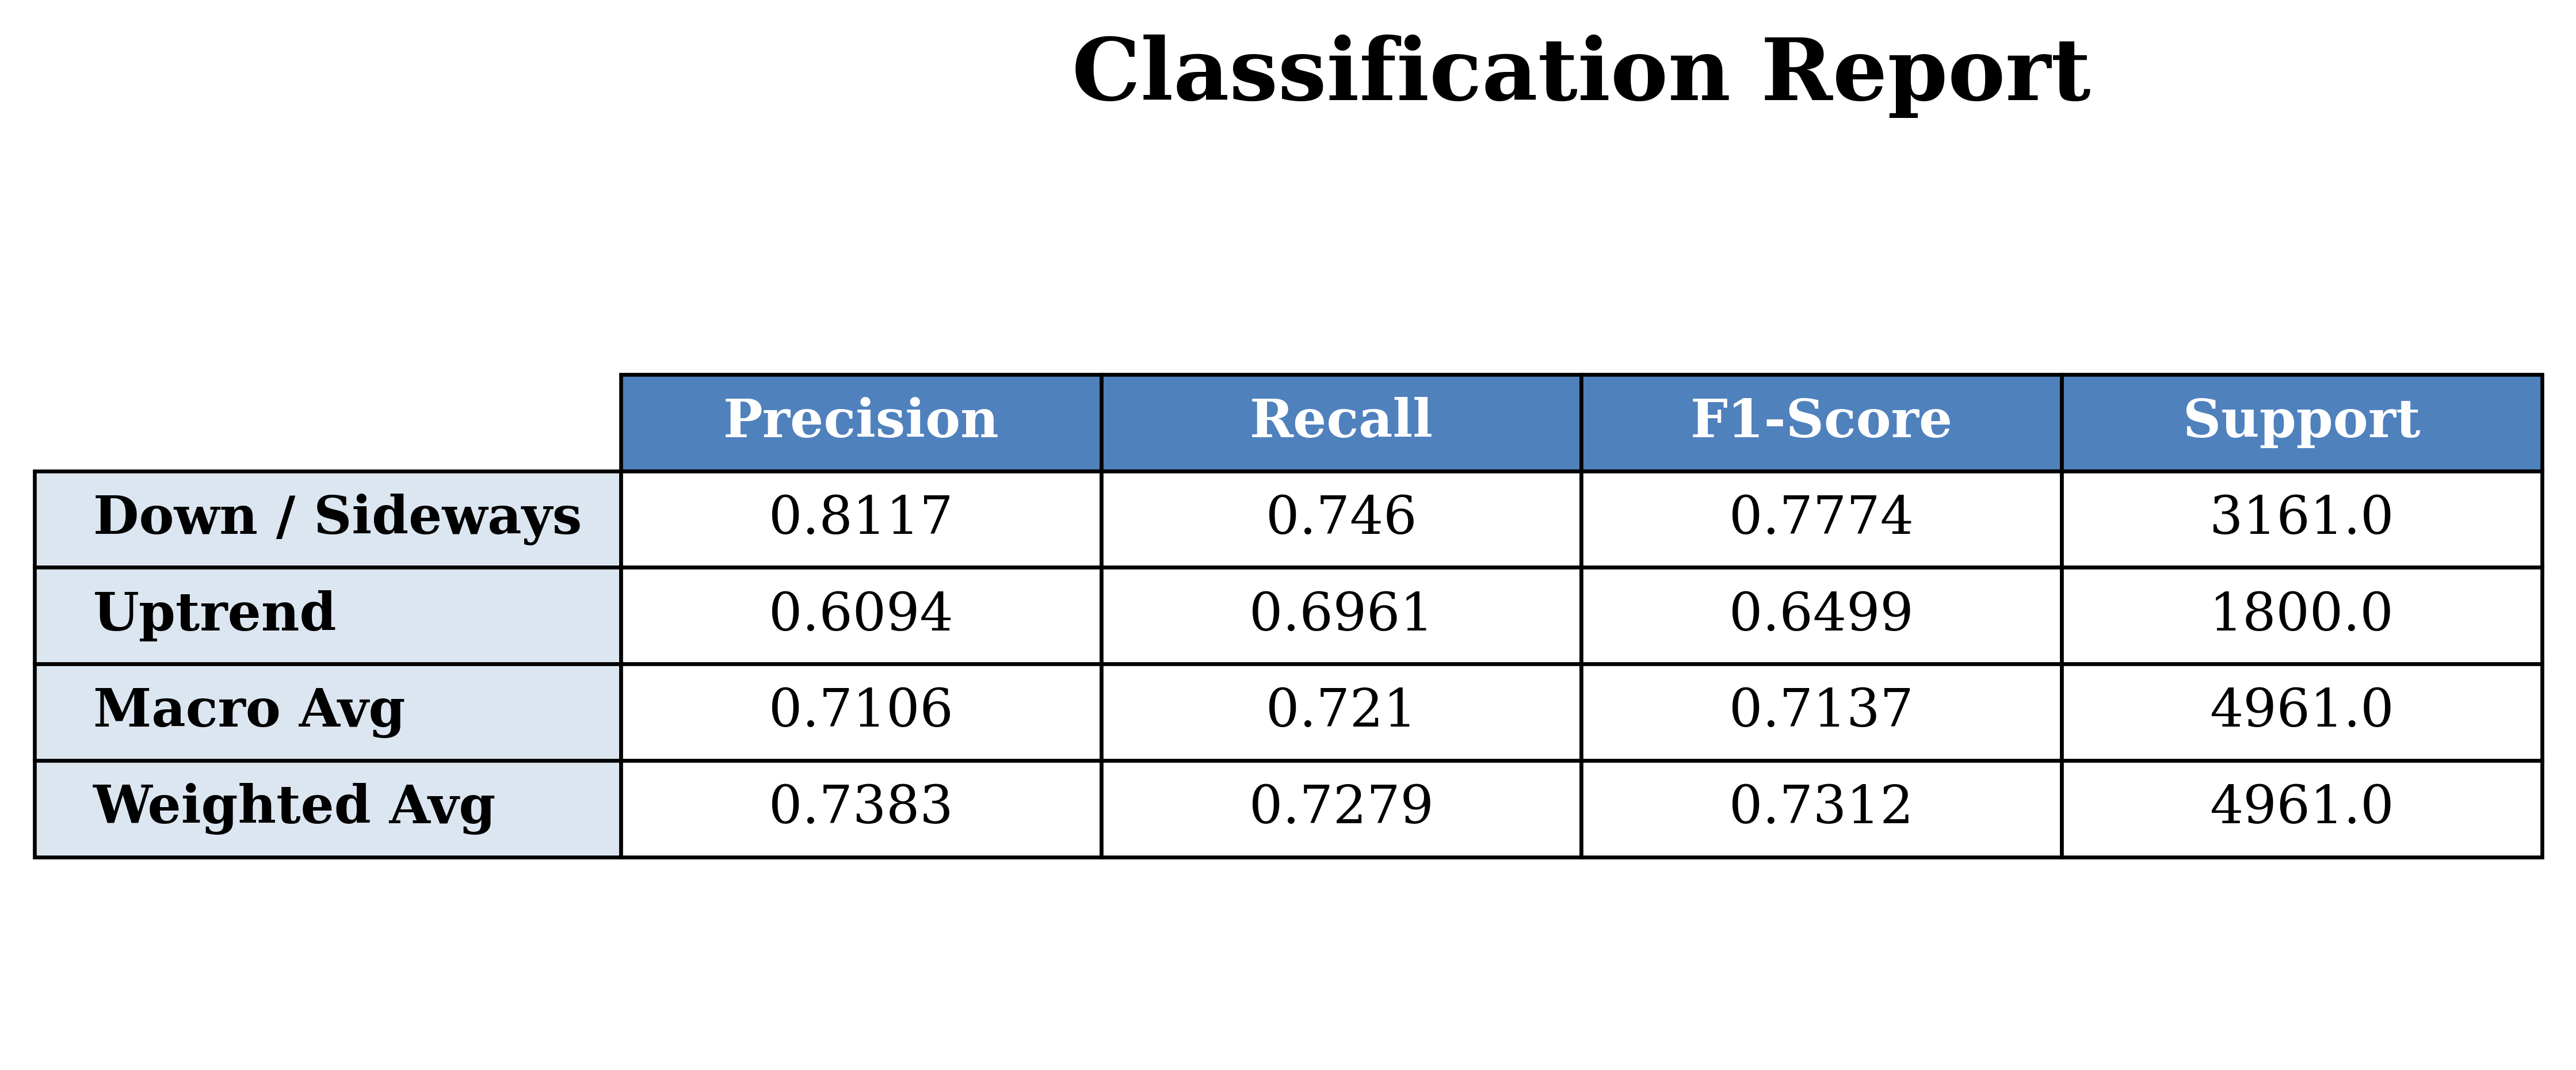

In [ ]:
# ============================================
# Classification Report Figure
# ============================================

report = classification_report(
    y_test,
    y_pred,
    target_names=[
        "Down / Sideways",
        "Uptrend"
    ],
    output_dict=True
)

report_df = pd.DataFrame(report).T

report_df = report_df.drop(index="accuracy")

report_df = report_df.rename(
    columns={
        "precision":"Precision",
        "recall":"Recall",
        "f1-score":"F1-Score",
        "support":"Support"
    }
)

report_df.rename(
    index={
        "macro avg": "Macro Avg",
        "weighted avg": "Weighted Avg"
    },
    inplace=True
)

report_df["Support"] = report_df["Support"].astype(int)

report_df = report_df.round(4)

plt.rcParams["font.family"] = "serif"

fig, ax = plt.subplots(
    figsize=(8,3.2),
    dpi=600
)

ax.axis("off")

table = ax.table(
    cellText=report_df.values,
    rowLabels=report_df.index,
    colLabels=report_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.25,1.7)

# ============================================
# Styling
# ============================================

for (row, col), cell in table.get_celld().items():

    cell.set_edgecolor("black")
    cell.set_linewidth(0.8)

    # Header
    if row == 0:
        cell.set_facecolor("#4F81BD")
        cell.set_text_props(
            color="white",
            weight="bold"
        )

    # Row labels
    if col == -1:
        cell.set_facecolor("#DCE6F1")
        cell.set_text_props(weight="bold")

ax.set_title(
    "Classification Report",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.savefig(
    "Classification_Report.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

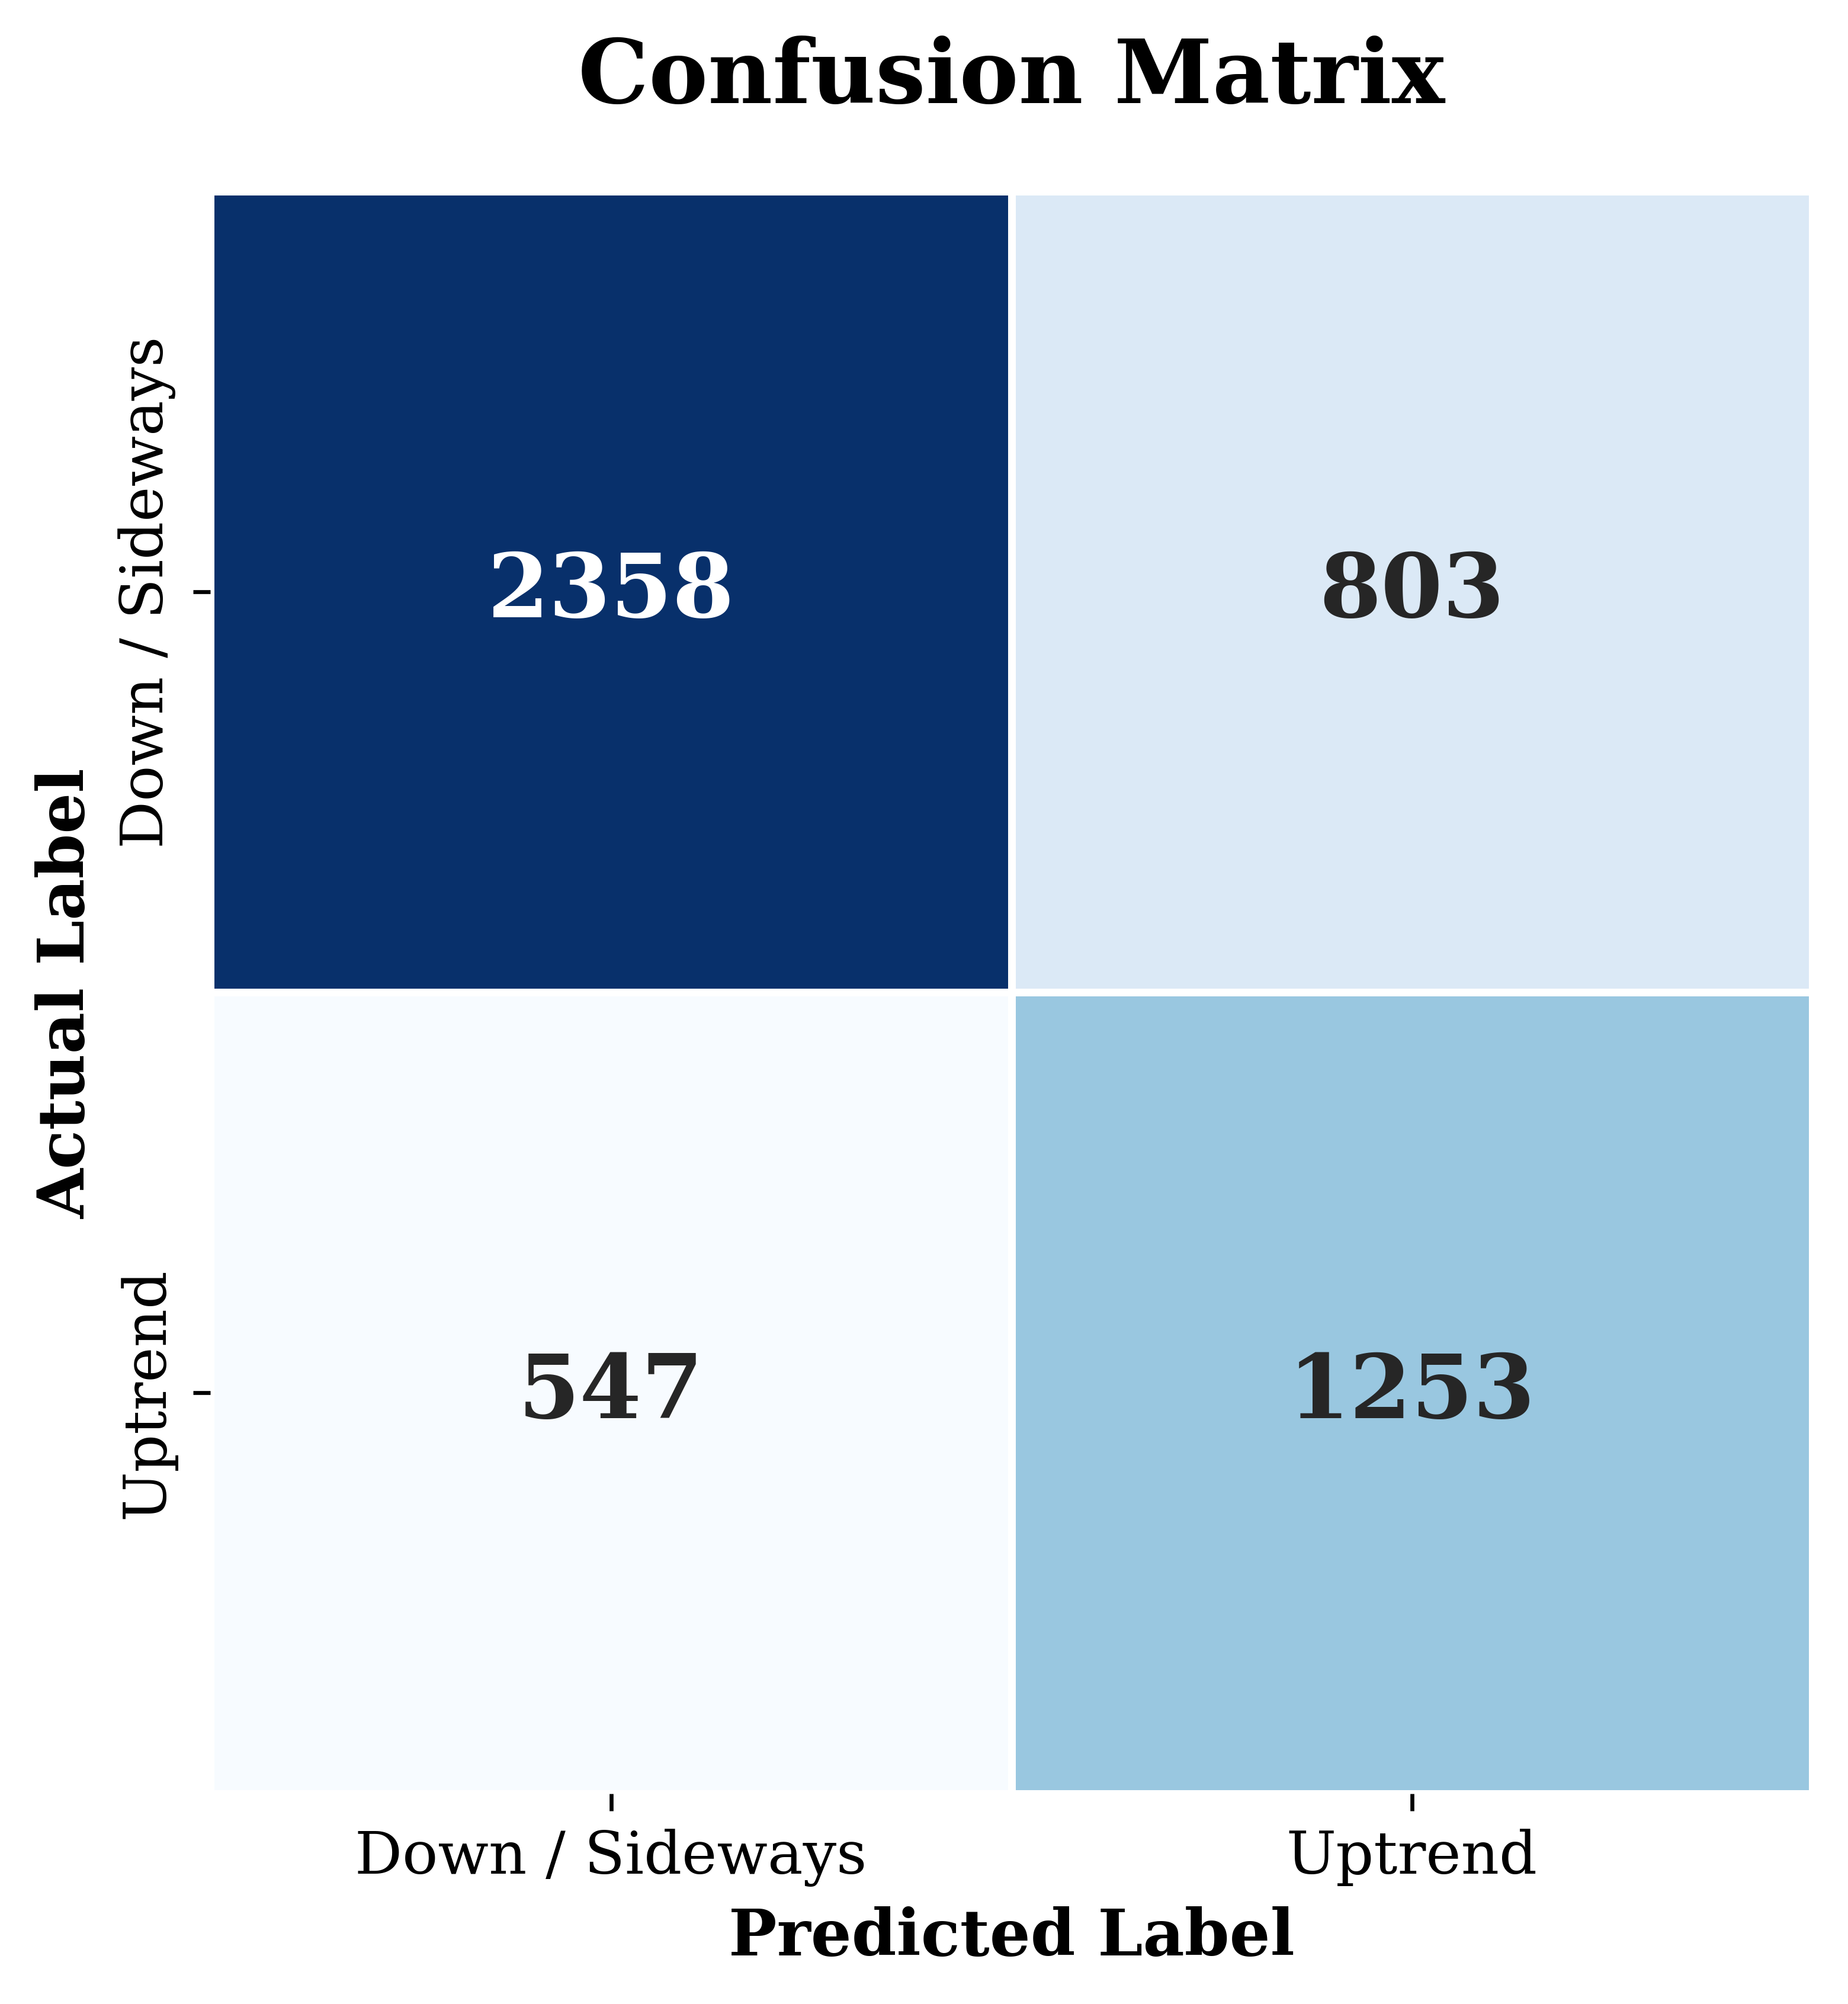

In [ ]:
# =========================================================
# Confusion Matrix
# =========================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6.8,5.8), dpi=600)

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1.5,
    cbar=False,
    square=True,
    annot_kws={
        "fontsize":18,
        "fontweight":"bold"
    }
)

ax.set_title(
    "Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Label",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticklabels(
    ["Down / Sideways","Uptrend"],
    fontsize=12
)

ax.set_yticklabels(
    ["Down / Sideways","Uptrend"],
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "Confusion_Matrix.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

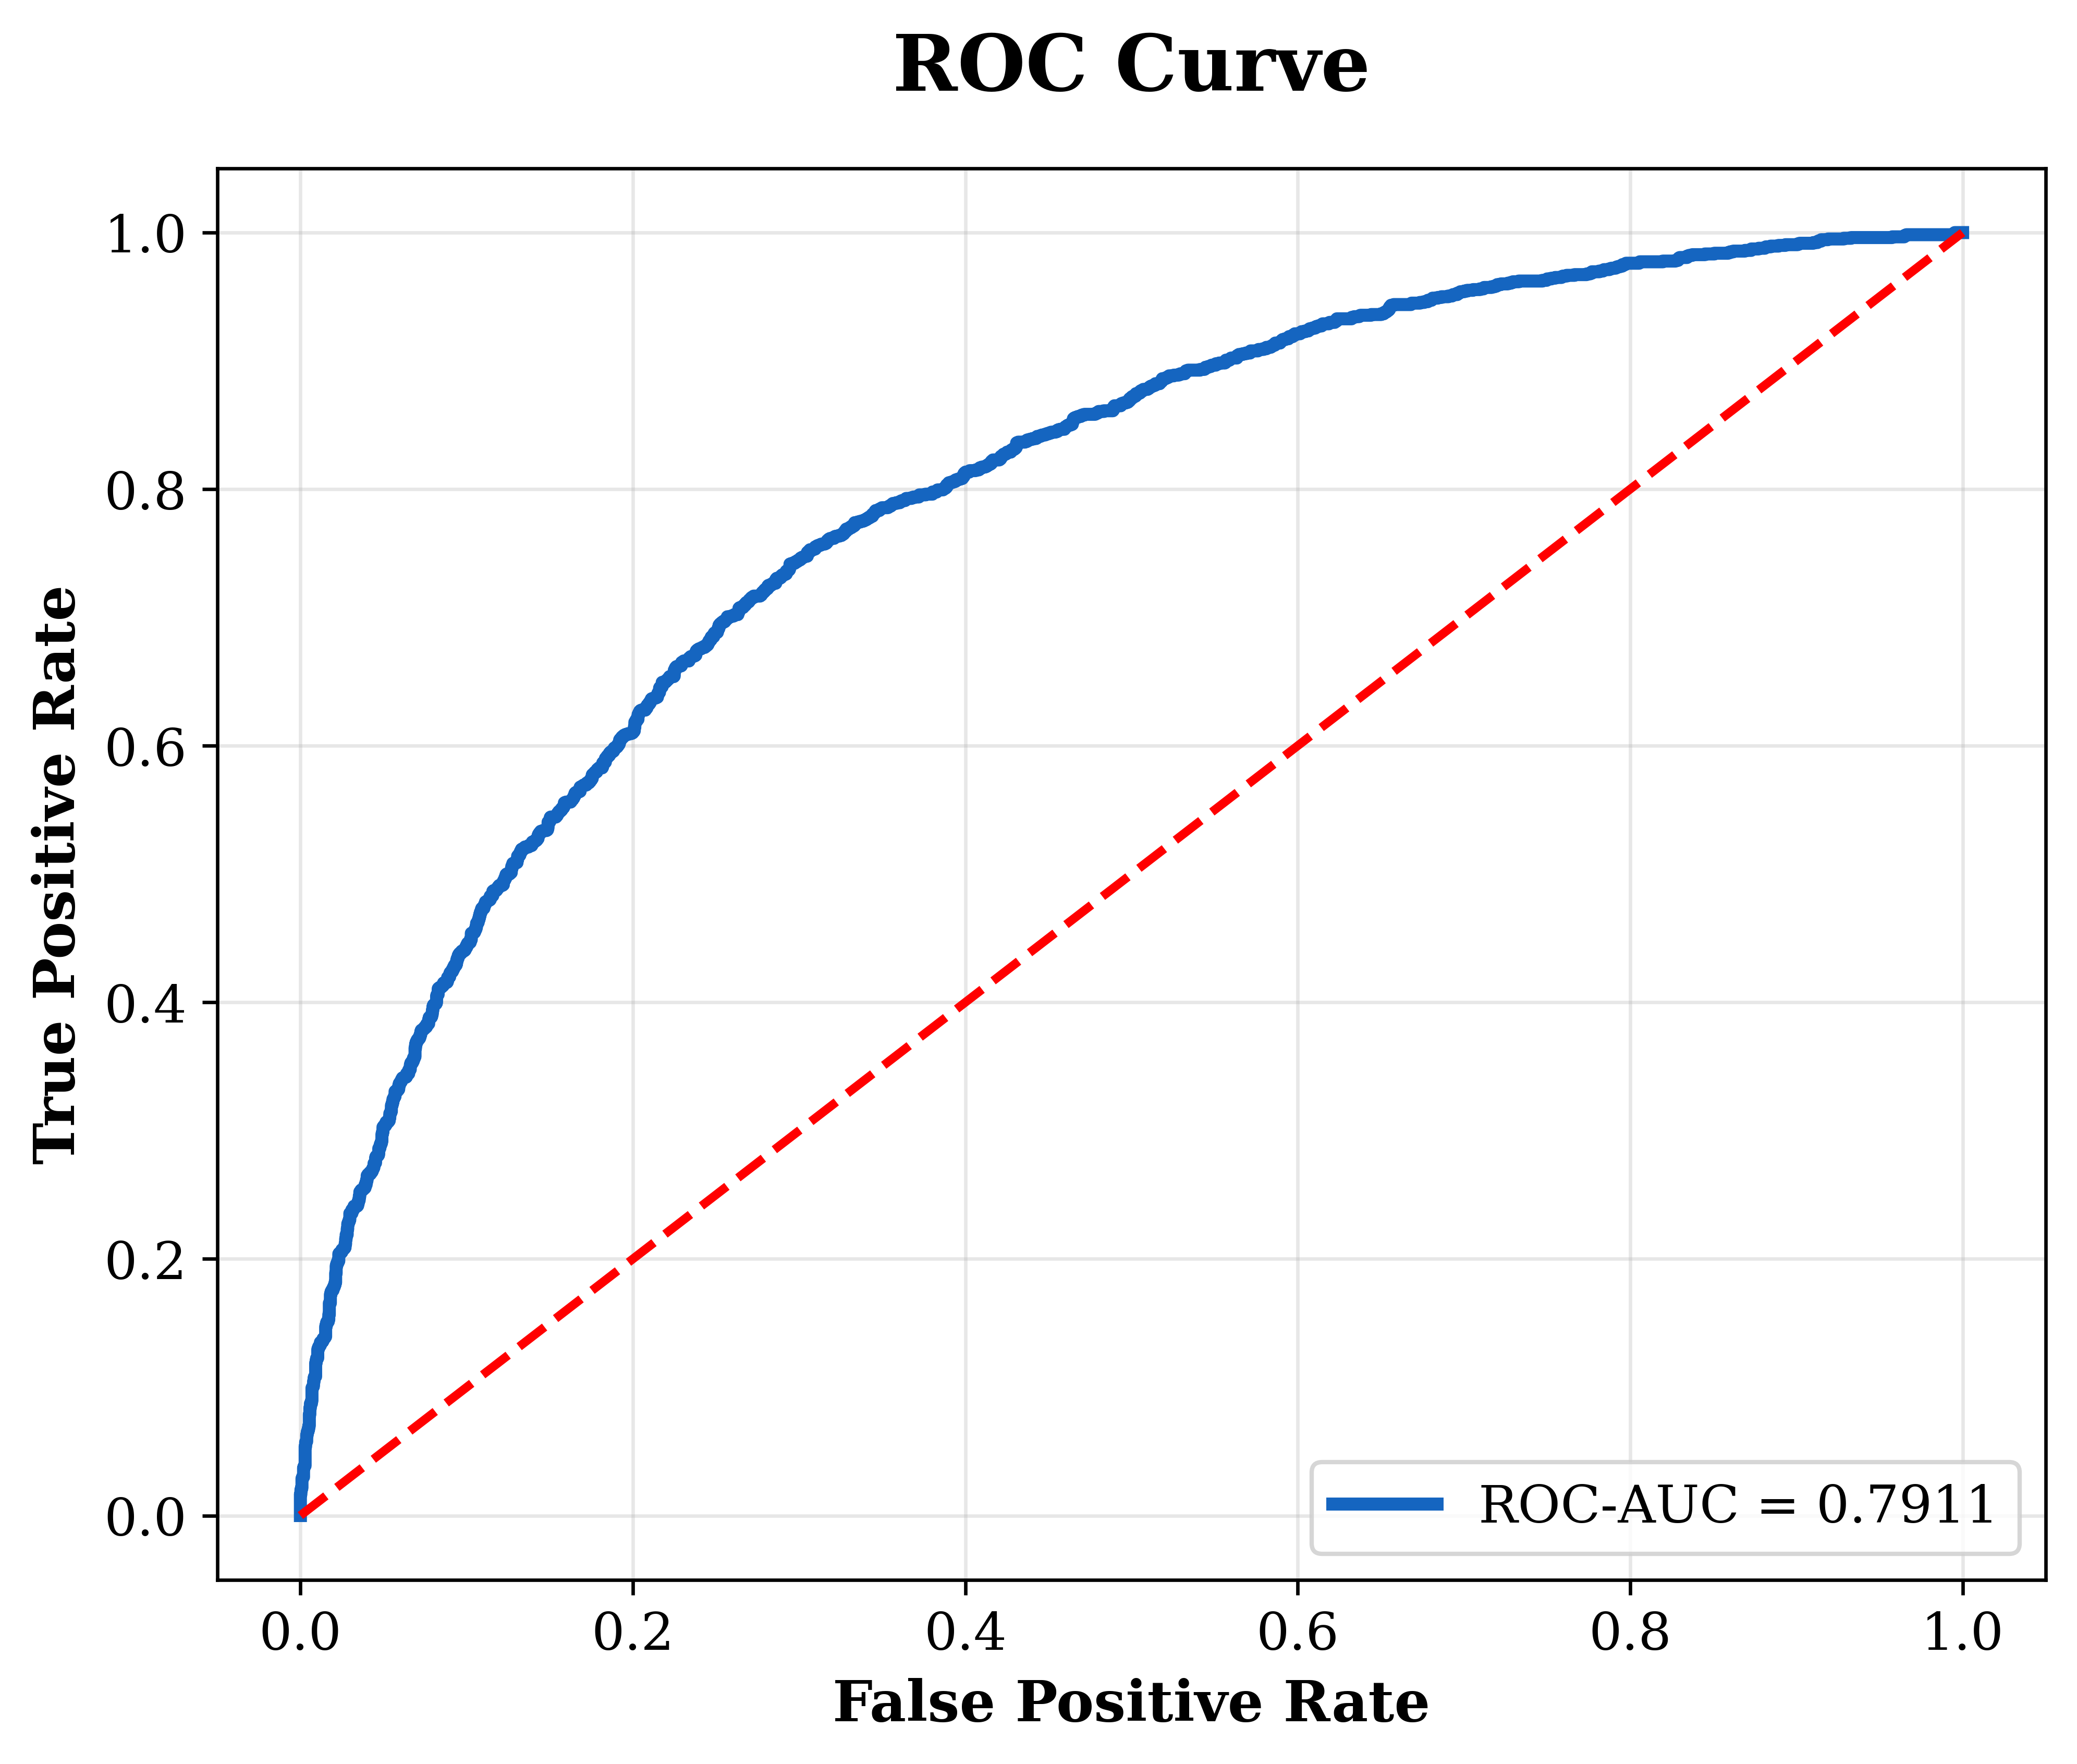

In [ ]:
# =========================================================
# ROC Curve
# =========================================================

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6.8,5.8), dpi=600)

plt.plot(
    fpr,
    tpr,
    color="#1565C0",
    linewidth=3,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    color="red"
)

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right",
    fontsize=12
)

plt.title(
    "ROC Curve",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "False Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "ROC_Curve.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

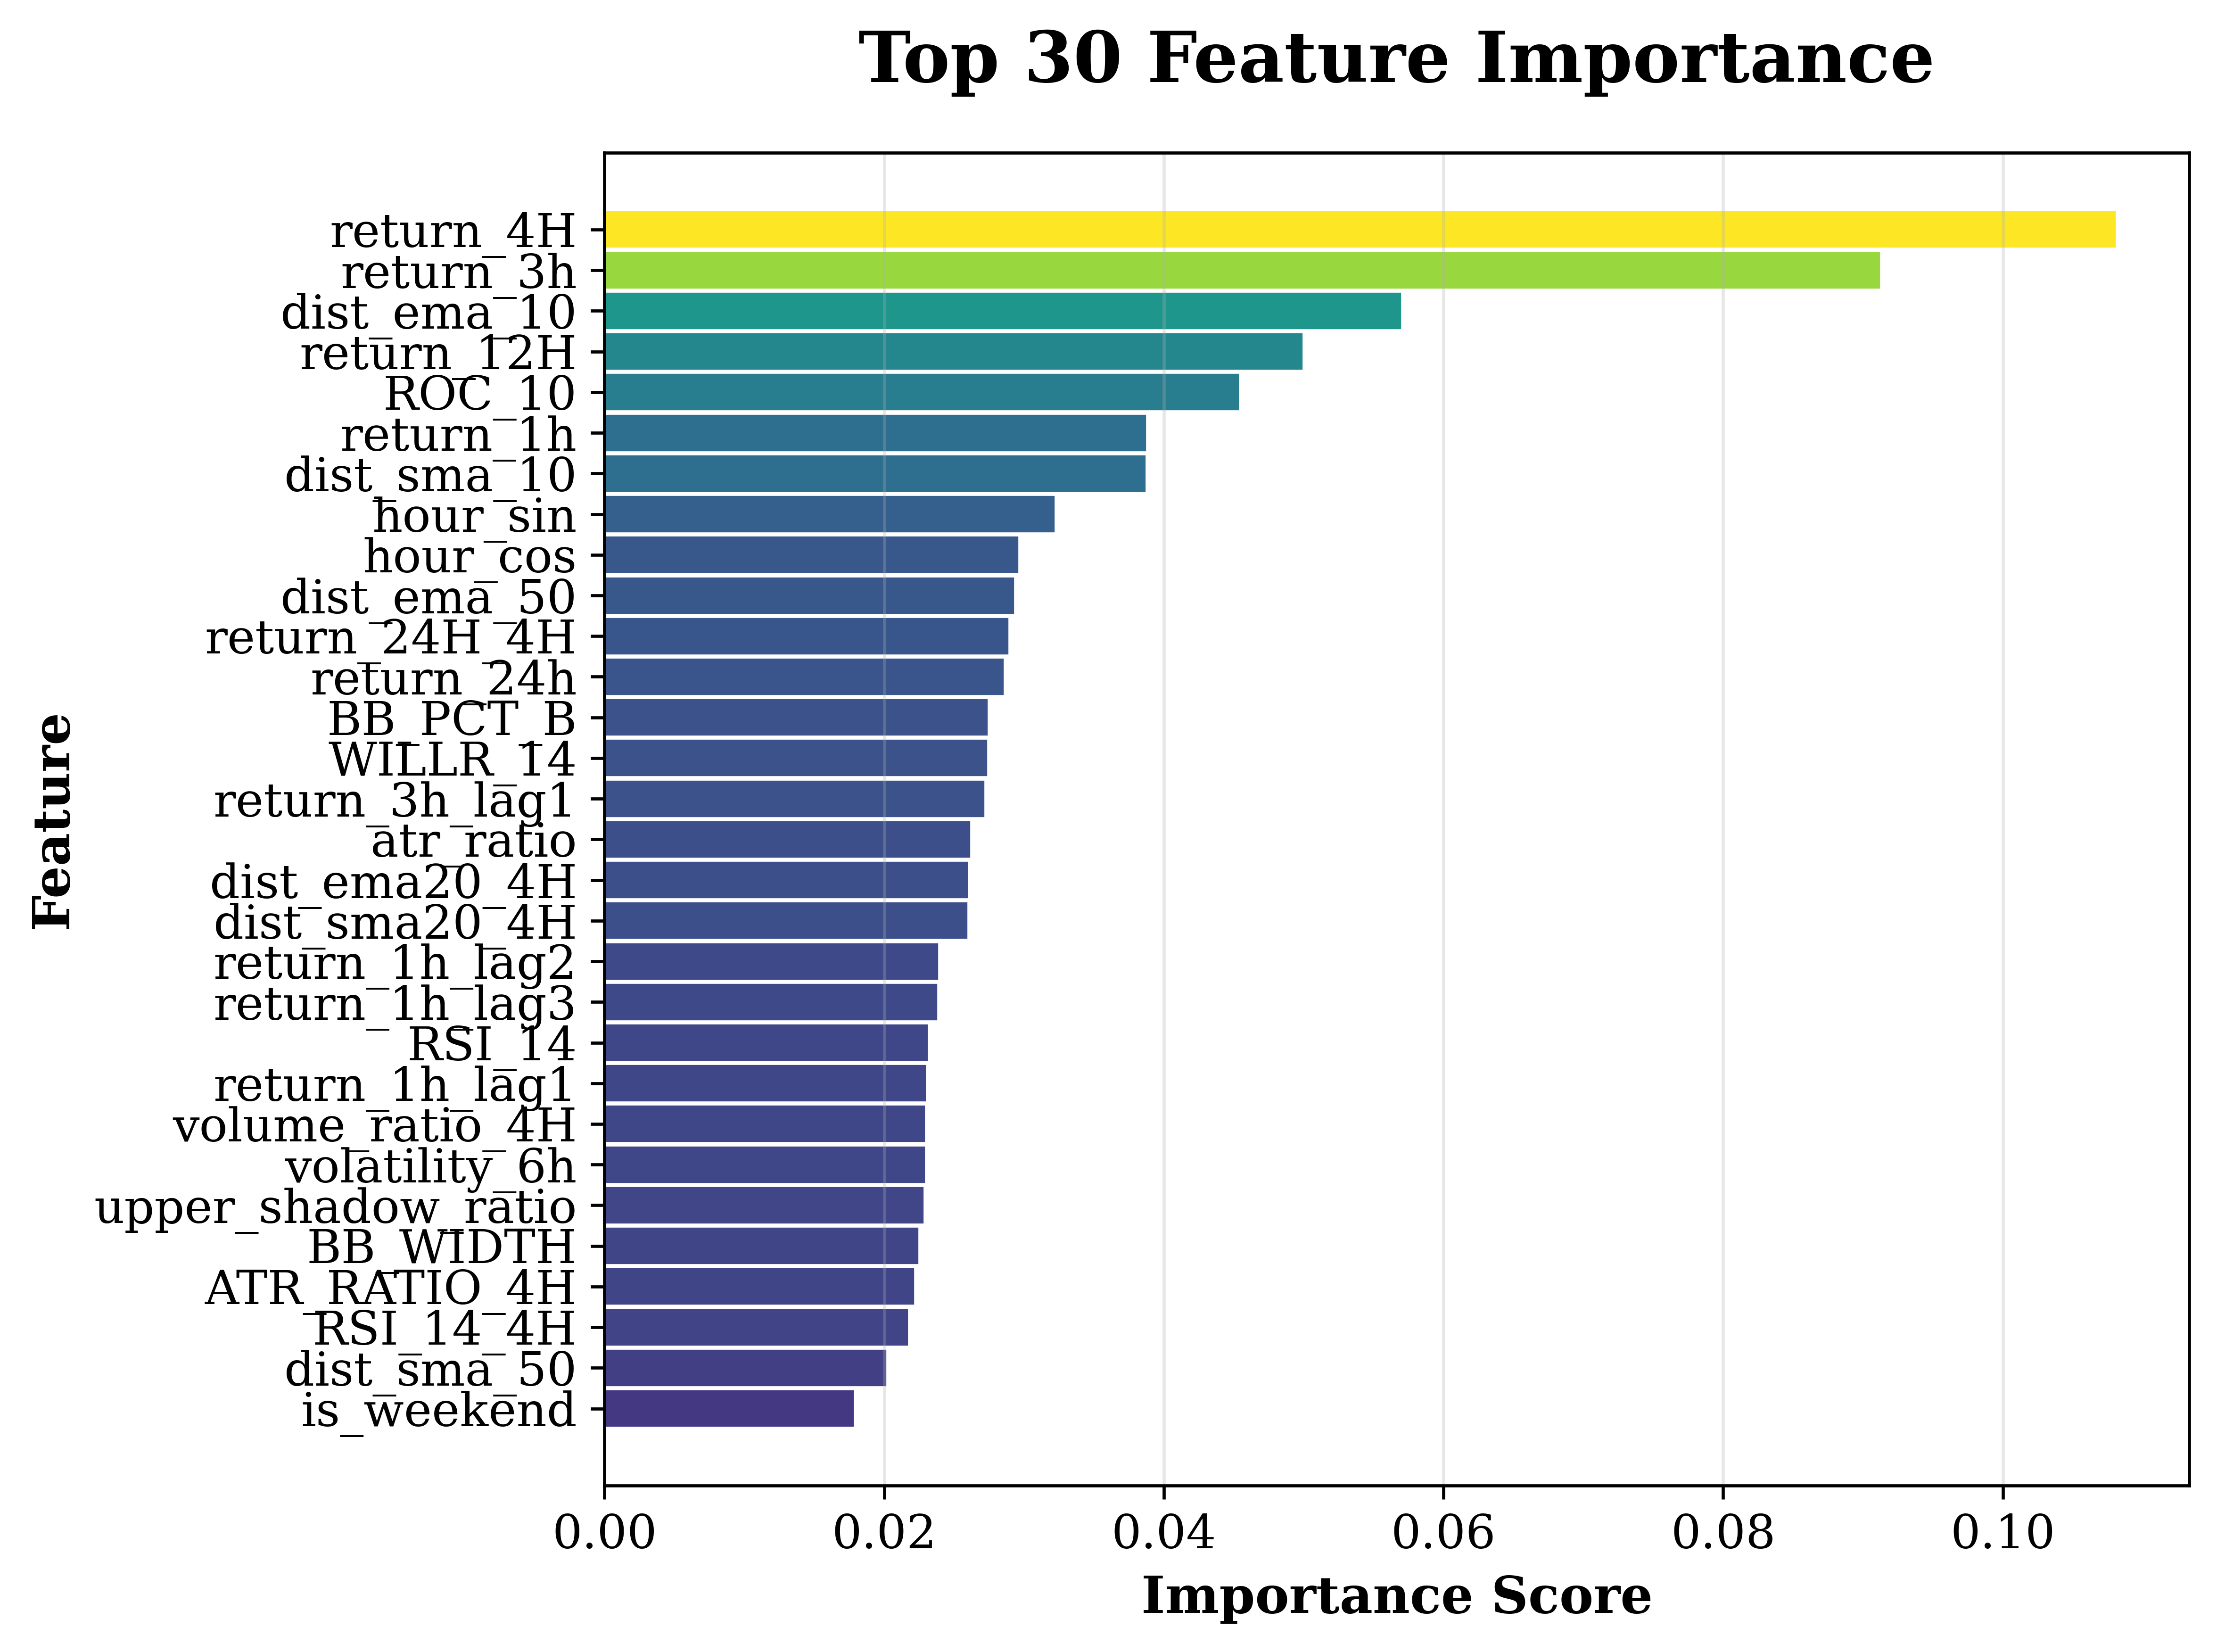

In [ ]:
# =========================================================
# Feature Importance
# =========================================================

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": final_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .head(30)
    .sort_values(
        by="Importance"
    )
)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 12

plt.figure(figsize=(8,6), dpi=600)

bars = plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"],
    edgecolor="black"
)

# gunakan colormap bawaan tanpa seaborn
colors = plt.cm.viridis(
    feature_importance["Importance"] /
    feature_importance["Importance"].max()
)

for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.title(
    "Top 30 Feature Importance",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Importance Score",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Feature",
    fontsize=13,
    fontweight="bold"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "Feature_Importance.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# =========================================================
# Save Model
# =========================================================

model_filename = 'xgboost_crypto_classifier.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)

In [ ]:
# =========================================================
# Save Feature Columns
# =========================================================

feature_filename = 'feature_columns.pkl'

with open(feature_filename, 'wb') as f:
    pickle.dump(selected_features, f)